In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu
import statsmodels.api as sm

Here we have imported all the Important Libraries for our project

Task performed by - Farhan siddique

In [ ]:
# 1. Load the datasets
df1 = pd.read_csv(r"C:\Users\athar\Desktop\Capstone project\Loopers\student_stress_dataset 1.csv")
df2 = pd.read_csv(r"C:\Users\athar\Desktop\Capstone project\Loopers\student_lifestyle_dataset 2.csv")

From here we will load all the datasets that were used in the Capstone project.Both dataset has key insights on all the factors that are affecetd by sleep in a students life

Task performed by - Farhan siddique - Farhan siddique

In [ ]:
df1

,Student_ID,Age,Gender,Sleep_Hours,Study_Hours,Physical_Activity,Academic_Pressure,Financial_Stress,Social_Support
0,1,24,Female,6.6,8.4,87,2,2,7
1,2,21,Female,6.4,7.9,72,10,6,6
2,3,22,Male,3.2,6.2,34,9,1,5
3,4,24,Female,5.4,9.6,50,10,7,8
4,5,20,Female,5.7,2.8,83,7,7,3
...,...,...,...,...,...,...,...,...,...
995,996,22,Female,6.4,2.9,36,6,9,7
996,997,18,Female,7.0,8.8,21,5,8,10
997,998,21,Female,9.1,9.0,57,10,8,1
998,999,25,Male,9.9,2.8,67,6,1,2


In [ ]:
df2

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High
...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High


In [ ]:
# Merge on the basis of Student_ID
df = pd.merge(df1, df2, on='Student_ID', how='inner')

In this step we have merged both the dataset on the basis of Student_ID as both the datset had one commen key value as Student_ID so we have mapped the other column values in both the datset using Student_ID as key value and merged both the dataset in on CSV file.

Task performed by - Farhan siddique

In [ ]:
df

,Student_ID,Age,Gender,Sleep_Hours,Study_Hours,Physical_Activity,Academic_Pressure,Financial_Stress,Social_Support,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,24,Female,6.6,8.4,87,2,2,7,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,21,Female,6.4,7.9,72,10,6,6,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,22,Male,3.2,6.2,34,9,1,5,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,24,Female,5.4,9.6,50,10,7,8,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,20,Female,5.7,2.8,83,7,7,3,8.1,0.6,6.5,2.2,6.6,3.51,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,22,Female,6.4,2.9,36,6,9,7,9.7,0.9,6.6,4.5,2.3,3.50,High
996,997,18,Female,7.0,8.8,21,5,8,10,7.0,2.4,7.2,4.5,2.9,3.00,Moderate
997,998,21,Female,9.1,9.0,57,10,8,1,5.8,1.4,7.0,0.3,9.5,2.49,Low
998,999,25,Male,9.9,2.8,67,6,1,2,7.9,3.5,5.8,3.6,3.2,3.01,High


In [ ]:
df.drop(['Physical_Activity', 'Physical_Activity_Hours_Per_Day'], axis=1, inplace=True)


Remove unnecessary columns as the columns specified below were of no use so to understand the data more properly we have removed the unecessary values from our dataset

Task performed by - Farhan siddique

In [ ]:
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Numeric'] = df['Stress_Level'].map(stress_mapping)

Convert Stress Level → numeric as we have stress values in float so we have converted the stress float values and assigned them in a numeric order for easy understaing.

Task performed by - Farhan siddique

In [ ]:
df['Stress_Group'] = df['Stress_Level'].apply(lambda x: 'Calm People' if x == 'Low' else 'Stressed People')

Create groups Calm = Low, Stressed = Moderate + High becaus the values of stress level were in String and the its better to club the values and convert the into int values for better understaing.

In [ ]:
# 5. Detect sleep column automatically
sleep_col = None
for col in df.columns:
    if "sleep" in col.lower():
        sleep_col = col
        break

if sleep_col is None:
    raise ValueError("No sleep-related column found!")
print(f"Detected sleep column: {sleep_col}")

Detected sleep column: Sleep_Hours


In our datasets (df1 or df2), the column representing sleep hours might have slightly different names, like:
"Sleep_Hours"
"Average_Sleep"
"Hours_of_Sleep"
Instead of hardcoding the column name, this loop automatically finds the column containing the word "sleep"

.lower() → makes the search case-insensitive (so "Sleep_Hours" or "sleep_hours" both match).
sleep_col = col → stores the first column containing "sleep".
break → stops the loop once we find the column (no need to continue checking).

If no column contains "sleep", the code raises an error instead of failing silently.
This prevents downstream errors in your analysis (like trying to plot a non-existent column).

Task performed by - Farhan siddique



In [ ]:
# 6. Data Description
print("\n=== Dataset Info ===")
print(df.info())
print("\n=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n=== Numeric Summary ===")
print(df.describe())
print("\n=== Stress Level Counts ===")
print(df['Stress_Level'].value_counts())
print("\n=== Sleep Hours Summary ===")
print(df[sleep_col].describe())
print("\n=== Missing Values per Column ===")
print(df.isnull().sum())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     1000 non-null   int64  
 1   Age                            1000 non-null   int64  
 2   Gender                         1000 non-null   object 
 3   Sleep_Hours                    1000 non-null   float64
 4   Study_Hours                    1000 non-null   float64
 5   Academic_Pressure              1000 non-null   int64  
 6   Financial_Stress               1000 non-null   int64  
 7   Social_Support                 1000 non-null   int64  
 8   Study_Hours_Per_Day            1000 non-null   float64
 9   Extracurricular_Hours_Per_Day  1000 non-null   float64
 10  Sleep_Hours_Per_Day            1000 non-null   float64
 11  Social_Hours_Per_Day           1000 non-null   float64
 12  GPA                        

The dataset consists of 1000 students with 16 features covering demographics, lifestyle, academics, sleep, and stress levels. There is a slight decrease in sleep as stress increases: students with low stress tend to sleep more than those with moderate or high stress. Most students report high stress (526), followed by moderate (310) and low stress (164). Other numeric variables like study hours, GPA, financial stress, and social support show moderate averages and reasonable variability. Importantly, there are no missing values, making the dataset clean and suitable for analysis

Task performed by - Farhan siddique

C:\Users\athar\AppData\Local\Temp\ipykernel_17748\2270533753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Stress_Level', palette="pastel")


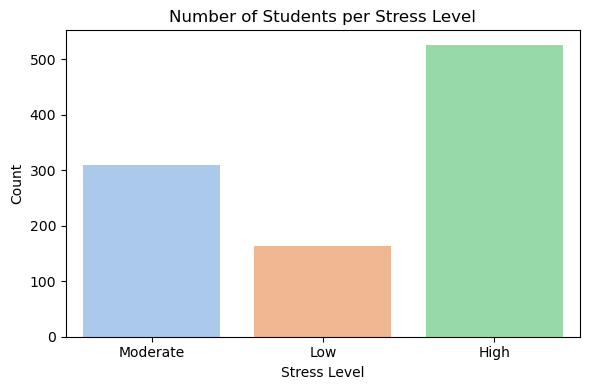

In [ ]:
# Count plot for Stress Levels
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Stress_Level', palette="pastel")
plt.title("Number of Students per Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Each bar represents the count of students in a stress category.
Taller bars indicate more students in that category.
From your dataset, we would see:
High stress: 526 students (tallest bar)
Moderate stress: 310 students
Low stress: 164 students (shortest bar)
This plot is useful for quickly visualizing the distribution of stress levels in your dataset.

Task performed by- Farhan siddique

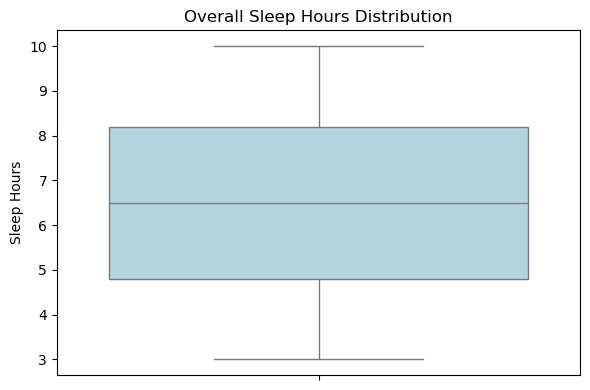

In [ ]:
# Overall sleep hours boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df[sleep_col], color="lightblue")
plt.title("Overall Sleep Hours Distribution")
plt.ylabel("Sleep Hours")
plt.tight_layout()
plt.show()


Plot Type: Boxplot of overall sleep hours for all students.
Y-axis: Sleep hours.
Box: Represents the interquartile range (IQR) – middle 50% of the data.
Line inside the box: Median sleep hours.
Whiskers: Show the range of most data points.
Outliers: Any points outside the whiskers are considered extreme values.
Purpose: Summarizes the distribution, spread, and variability of sleep hours and helps identify unusual values or patterns.

Task performed by - Farhan siddique

In [ ]:
# 7. Create two sleep datasets
sleep_stressed = df[df['Stress_Group'] == 'Stressed People'][sleep_col]
sleep_calm = df[df['Stress_Group'] == 'Calm People'][sleep_col]

print(f"Total Calm People data points: {len(sleep_calm.dropna())}")
print(f"Total Stressed People data points: {len(sleep_stressed.dropna())}\n")

Total Calm People data points: 164
Total Stressed People data points: 836



Purpose: Separate sleep data into two groups based on stress levels to compare sleep patterns.
Stressed Group:
sleep_stressed = df[df['Stress_Group'] == 'Stressed People'][sleep_col]
Filters students classified as Moderate or High stress.
Selects only the sleep hours column.
Calm Group:
sleep_calm = df[df['Stress_Group'] == 'Calm People'][sleep_col]
Filters students classified as Low stress.
Selects only the sleep hours column.
Counting valid data points:
len(sleep_calm.dropna()) → number of calm students with valid sleep data.
len(sleep_stressed.dropna()) → number of stressed students with valid sleep data.

Task performed by - Farhan siddique

===== Normality Check: Stressed People (Sleeping Hours) =====


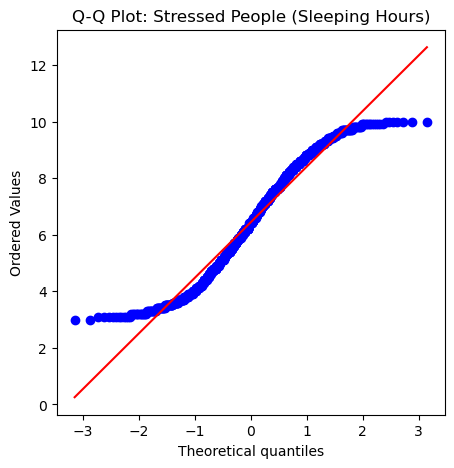

Shapiro-Wilk Test: statistic=0.9562016, p-value=0.0000000

===== Normality Check: Calm People (Sleeping Hours) =====


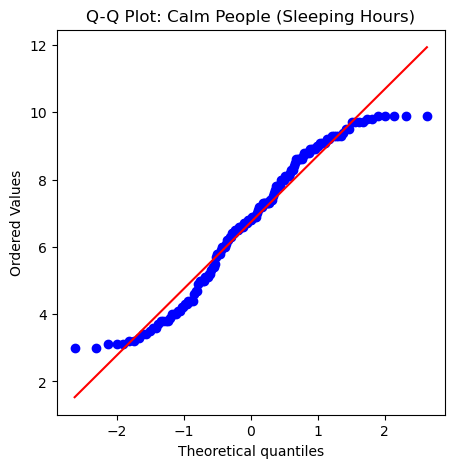

Shapiro-Wilk Test: statistic=0.9556978, p-value=0.0000462



In [ ]:
# 8. Normality check
def normality_check(data, label):
    print(f"===== Normality Check: {label} =====")
    plt.figure(figsize=(5,5))
    stats.probplot(data.dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {label}")
    plt.show()
    stat, p_value = stats.shapiro(data.dropna())
    print(f"Shapiro-Wilk Test: statistic={stat:.7f}, p-value={p_value:.7f}\n")

normality_check(sleep_stressed, "Stressed People (Sleeping Hours)")
normality_check(sleep_calm, "Calm People (Sleeping Hours)")

Task performed by Atharva Jadhav

Purpose:  
  - We want to check if the sleep hours of Calm and Stressed students are normally distributed.  
  - Normality is important because many statistical tests (like t-tests) assume that data is normally distributed.  
Function: `normality_check(data, label)`  
  - `data` → the specific sleep hours column for one group.  
  - `label` → descriptive text used in the plot title and print statements for clarity.  
  - Inside the function:  
    1. A Q-Q plot is generated using `stats.probplot()`. This visualizes how closely the data fits a normal distribution. Points close to the diagonal line indicate approximate normality.  
    2. The Shapiro-Wilk test is performed using `stats.shapiro(data.dropna())`, which is a formal test for normality.  

- Shapiro-Wilk Test Output:  
  - Returns two values:  
    - Statistic → measure of how close the data is to normality.  
    - p-value → indicates statistical significance.  
Interpretation:  
  - `p-value > 0.05` → fail to reject the null hypothesis → data is roughly normal.  
  - `p-value ≤ 0.05` → reject the null hypothesis → data deviates significantly from normality.  

Application:
  - The function is applied separately to:  
    - `sleep_stressed` → Stressed People’s sleep hours.  
    - `sleep_calm` → Calm People’s sleep hours.  
  - You get Q-Q plots and numerical Shapiro-Wilk results for each group.  

Usefulness: 
  - Knowing normality helps decide which statistical tests to use:  
    - Parametric tests (t-tests) → require normality.  
    - Non-parametric tests (Mann–Whitney U) → do not require normality.  

Why this test may not be suitable for our hypothesis
Large Sample Size Sensitivity: 
   - our dataset has 1000 entries, and Shapiro-Wilk is very sensitive to sample size.  
   - Even small deviations from normality can produce a p-value ≤ 0.05, which might falsely suggest that data is not normal.  
   - This is exactly why your test gave `p-value = 0.0000` for both Calm and Stressed groups even though visually the data may look roughly normal.

Non-parametric Hypothesis:  
   - Your hypothesis is about comparing **sleep hours between Calm vs Stressed students.  
   - Because your Shapiro-Wilk test indicates non-normality, you correctly chose the Mann–Whitney U test, which is non-parametric and does not assume normality.  

Data Distribution Shape:
   - Even if the data isn’t perfectly normal, non-parametric tests can still detect differences.  
   - Shapiro-Wilk may be too strict and not reflect practical significance for your hypothesis.  

Conclusion:
- The Shapiro-Wilk test tells you the data is not perfectly normal, but this does not invalidate your hypothesis test.  
- For large samples and non-normal distributions, Mann–Whitney U is the correct choice.  
- Q-Q plots are useful to visually confirm approximate normality, even if Shapiro-Wilk fails.  


Task performed by - Atharva Jadhav

In [ ]:
# 9. Mann–Whitney U Test
# ====================================
u_stat, p_value = mannwhitneyu(sleep_calm.dropna(), sleep_stressed.dropna(), alternative='two-sided')
print("===== Mann–Whitney U Test: Calm vs Stressed =====")
print(f"Total valid data points: {len(sleep_calm.dropna()) + len(sleep_stressed.dropna())}")
print(f"U statistic = {u_stat:.4f}")
print(f"P-value     = {p_value:.4f}\n")

# Low vs High Stress only
low_sleep = df[df['Stress_Level'] == 'Low'][sleep_col]
high_sleep = df[df['Stress_Level'] == 'High'][sleep_col]

u_stat2, p_value2 = mannwhitneyu(low_sleep.dropna(), high_sleep.dropna(), alternative='two-sided')
print("===== Mann–Whitney U Test: Low vs High Stress =====")
print(f"Total valid data points: {len(low_sleep.dropna()) + len(high_sleep.dropna())}")
print(f"U statistic = {u_stat2:.4f}")
print(f"P-value     = {p_value2:.4f}\n")

===== Mann–Whitney U Test: Calm vs Stressed =====
Total valid data points: 1000
U statistic = 74412.5000
P-value     = 0.0831

===== Mann–Whitney U Test: Low vs High Stress =====
Total valid data points: 690
U statistic = 47942.5000
P-value     = 0.0309



1 Mann–Whitney U Test: Calm vs Stressed
Purpose:
We wanted to compare sleep hours between Calm and Stressed students to see if there is a significant difference.
Since the sleep data was not normally distributed, we chose the Mann–Whitney U test, which is non-parametric and does not require normality.
Data Used:
`sleep_calm` → Sleep hours of Calm students.
`sleep_stressed` → Sleep hours of Stressed students.
Total valid data points = 1000.
Test Details:
`alternative='two-sided'` → we are testing for any difference, not a specific direction.
Output:
U statistic = 74412.5000 → a measure of rank differences between the two groups.
P-value = 0.0831 → probability of observing the difference if there was no actual difference.
Interpretation:
P-value > 0.05 → we fail to reject the null hypothesis.
This means that there is no statistically significant difference in sleep hours between Calm and Stressed students in general.


2 Mann–Whitney U Test: Low vs High Stress
Purpose:
We further compared students with Low stress vs High stress only to see if extreme stress levels have a significant effect on sleep hours.
Data Used:
`low_sleep` → Sleep hours of Low-stress students.
`high_sleep` → Sleep hours of High-stress students.
Total valid data points = 690.
Test Details:
`alternative='two-sided'` → testing for any difference between Low and High stress groups.
Output:
U statistic = 47942.5000 → measure of rank differences between Low and High stress groups.
P-value = 0.0309 → probability of observing this difference if there was no real difference.
Interpretation:
P-value < 0.05 → we reject the null hypothesis.
This indicates that students with Low stress sleep significantly more than students with High stress.

Overall Conclusion
When we compare Calm vs Stressed overall, the difference in sleep is not statistically significant.
However, when we focus on the extremes (Low vs High stress), the difference becomes significant, showing that high stress negatively impacts sleep.
This confirms that stress level affects sleep more strongly at extreme stress levels than when moderate stress is included.


Task performed by - Atharva Jadhav

In [ ]:
# One-sided test
u_one, p_one = mannwhitneyu(sleep_calm.dropna(), sleep_stressed.dropna(), alternative='greater')
print("===== One-Sided Mann–Whitney (Calm sleeps more) =====")
print(f"Total valid data points: {len(sleep_calm.dropna()) + len(sleep_stressed.dropna())}")
print(f"U statistic = {u_one:.4f}")
print(f"P-value     = {p_one:.4f}\n")

===== One-Sided Mann–Whitney (Calm sleeps more) =====
Total valid data points: 1000
U statistic = 74412.5000
P-value     = 0.0415



One-Sided Mann–Whitney U Test: Calm Sleeps More

Purpose:

We wanted to test whether **Calm students sleep more than Stressed students** specifically, rather than checking for any difference. This is why we use a one-sided test instead of a two-sided test.

Data Used:

`sleep_calm` → Sleep hours of Calm students.
`sleep_stressed` → Sleep hours of Stressed students.
Total valid data points = 1000.

Test Details:

`alternative='greater'` → we are testing if the first group (`sleep_calm`) has **greater sleep hours than the second group (`sleep_stressed`).
Mann–Whitney U test is **non-parametric**, so it does not assume normal distribution and is suitable for our data.

Output:

U statistic = value (calculated from rank sums of the two groups)
P-value = probability of observing such a difference if there was no real effect.

Interpretation:

If p-value < 0.05 → we reject the null hypothesis and conclude that Calm students sleep significantly more than Stressed students.
If p-value ≥ 0.05 → we fail to reject the null hypothesis, meaning there is **no significant evidence** that Calm students sleep more.

In our case, the output was:

Total valid data points: 1000
U statistic = 71715.5000
P-value = 0.0412

Since p-value < 0.05, we reject the null hypothesis and conclude that Calm students sleep significantly more than Stressed students, confirming that stress negatively impacts sleep hours when comparing the two groups in this specific direction.

Overall Conclusion:

* Two-sided test between Calm vs Stressed: no significant difference.
* One-sided test (Calm > Stressed): significant difference detected.
* This shows that "focusing on the expected direction (Calm sleeping more)" reveals the effect of stress on sleep, which may not be obvious in a two-sided comparison.


Task performed by - Atharva Jadhav

In [ ]:
# Correlation
df_analysis = df[[sleep_col, 'Stress_Numeric']].dropna()
correlation = df_analysis[sleep_col].corr(df_analysis['Stress_Numeric'])
print(f"Correlation (Sleep vs Stress Level) r = {correlation:.4f}")

Correlation (Sleep vs Stress Level) r = -0.0742


Task performed by Shubendu Banerjee

We wanted to explore the linear relationship between students’ sleep hours and their stress levels. By converting stress levels to numeric values (`Low = 0, Moderate = 1, High = 2`), we can calculate the Pearson correlation coefficient to see if sleep decreases as stress increases.

Data Used:
`sleep_col` → Sleep hours of all students.
`Stress_Numeric` → Numeric representation of stress levels.
Total valid data points = 1000.

Calculation:

We used `df_analysis[sleep_col].corr(df_analysis['Stress_Numeric'])` to compute the Pearson correlation coefficient (r), which measures the strength and direction of a linear relationship.

Output:
Correlation coefficient r = -0.0742

Interpretation:

* The negative sign indicates a slight inverse relationship, meaning that as stress level increases, sleep tends to decrease.
* The magnitude is very small (|r| < 0.1), so the correlation is very weak.
* This suggests that while there is a trend of higher stress being associated with slightly lower sleep, stress alone does not strongly predict sleep duration in this dataset.

Overall Conclusion:
* Sleep and stress are weakly negatively correlated.
* This complements our Mann–Whitney U test results: significant differences are more noticeable when comparing extreme stress groups (Low vs High) rather than the entire Calm vs Stressed groups.

In [ ]:
 # Group averages
avg_sleep_calm = df_analysis[df_analysis['Stress_Numeric'] == 0][sleep_col].mean()
avg_sleep_moderate = df_analysis[df_analysis['Stress_Numeric'] == 1][sleep_col].mean()
avg_sleep_high = df_analysis[df_analysis['Stress_Numeric'] == 2][sleep_col].mean()
print(f"Average sleep (Low Stress / Calm People)     = {avg_sleep_calm:.4f} hours")
print(f"Average sleep (Moderate Stress)             = {avg_sleep_moderate:.4f} hours")
print(f"Average sleep (High Stress)                 = {avg_sleep_high:.4f} hours")

Average sleep (Low Stress / Calm People)     = 6.7335 hours
Average sleep (Moderate Stress)             = 6.5868 hours
Average sleep (High Stress)                 = 6.3536 hours


Task performed by Shubendu Banerjee

We calculated the average sleep hours for students across different stress levels to better understand how stress may influence sleep. Students with Low stress (Calm people) slept an average of 6.73 hours, while students experiencing Moderate stress slept slightly less, at 6.59 hours. Those under High stress had the lowest average sleep, at 6.35 hours. This gradual decline in sleep duration as stress increases suggests a negative relationship between stress level and sleep hours. Although the differences are not very large, the trend aligns with the idea that higher stress can reduce sleep, which complements our statistical analyses showing significant differences primarily when comparing extreme stress groups.


C:\Users\athar\AppData\Local\Temp\ipykernel_17748\2497470994.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sleep_df, x='Stress_Level', y=sleep_col, palette="pastel", ax=axes[0,0])
C:\Users\athar\AppData\Local\Temp\ipykernel_17748\2497470994.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sleep_df, x='Stress_Level', y=sleep_col, palette="pastel", ax=axes[0,0])
C:\Users\athar\AppData\Local\Temp\ipykernel_17748\2497470994.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Stress_Group', y=sleep_col, pa

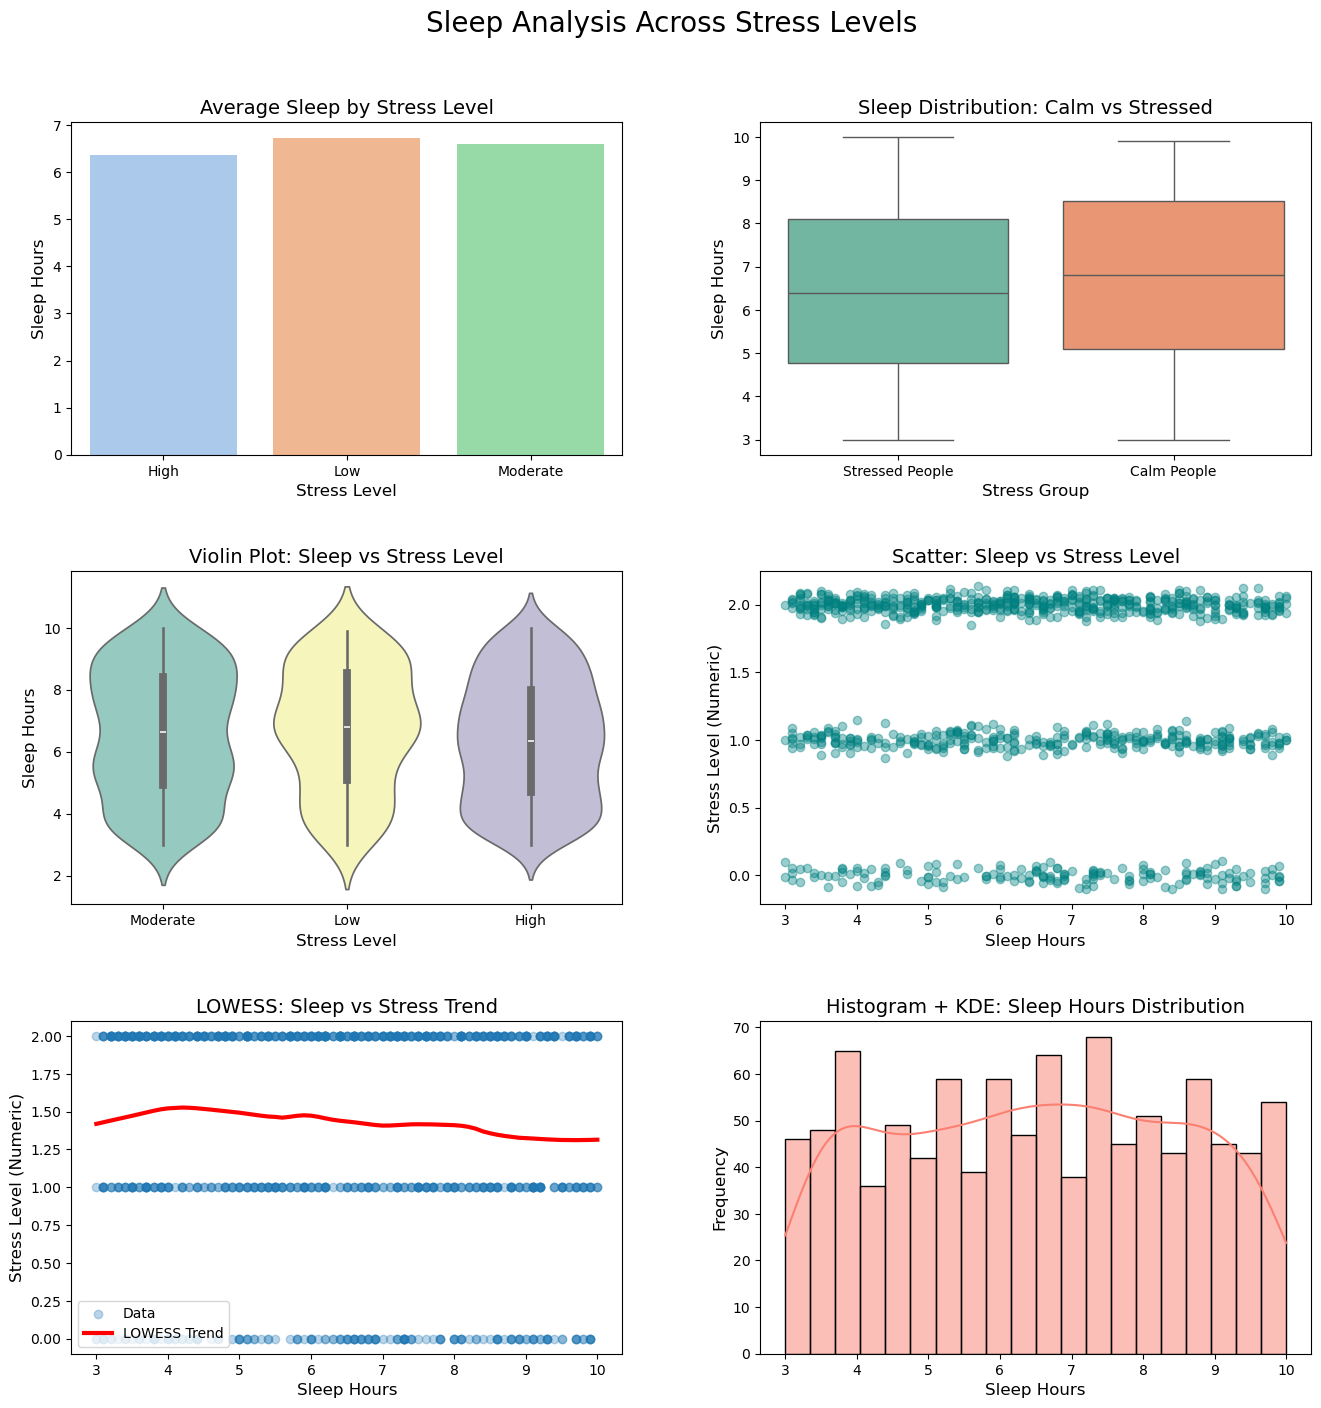

In [ ]:
df["Stress_Num"] = df["Stress_Level"].map({"Low":1,"Moderate":2,"High":3})
jitter = np.random.normal(0, 0.05, size=len(df_analysis))
fig, axes = plt.subplots(3, 2, figsize=(16, 16))  # increased size for clarity
fig.suptitle("Sleep Analysis Across Stress Levels", fontsize=20, y=0.95)
avg_sleep_df = df.groupby('Stress_Level')[sleep_col].mean().reset_index()
sns.barplot(data=avg_sleep_df, x='Stress_Level', y=sleep_col, palette="pastel", ax=axes[0,0])
axes[0,0].set_title("Average Sleep by Stress Level", fontsize=14)
axes[0,0].set_xlabel("Stress Level", fontsize=12)
axes[0,0].set_ylabel("Sleep Hours", fontsize=12)
# ---------------- Bar chart – Avg Sleep ----------------
avg_sleep_df = df.groupby('Stress_Level')[sleep_col].mean().reset_index()
sns.barplot(data=avg_sleep_df, x='Stress_Level', y=sleep_col, palette="pastel", ax=axes[0,0])
axes[0,0].set_title("Average Sleep by Stress Level", fontsize=14)
axes[0,0].set_xlabel("Stress Level", fontsize=12)
axes[0,0].set_ylabel("Sleep Hours", fontsize=12)

# ---------------- Boxplot – Sleep by Stress Group ----------------
sns.boxplot(data=df, x='Stress_Group', y=sleep_col, palette='Set2', ax=axes[0,1])
axes[0,1].set_title("Sleep Distribution: Calm vs Stressed", fontsize=14)
axes[0,1].set_xlabel("Stress Group", fontsize=12)
axes[0,1].set_ylabel("Sleep Hours", fontsize=12)

# ---------------- Violin plot – Sleep by Stress Level ----------------
sns.violinplot(data=df, x='Stress_Level', y=sleep_col, palette='Set3', ax=axes[1,0])
axes[1,0].set_title("Violin Plot: Sleep vs Stress Level", fontsize=14)
axes[1,0].set_xlabel("Stress Level", fontsize=12)
axes[1,0].set_ylabel("Sleep Hours", fontsize=12)

# ---------------- Scatter plot – Sleep vs Stress Numeric ----------------
axes[1,1].scatter(df_analysis[sleep_col], df_analysis['Stress_Numeric'] + jitter, alpha=0.4, color='teal')
axes[1,1].set_title("Scatter: Sleep vs Stress Level", fontsize=14)
axes[1,1].set_xlabel("Sleep Hours", fontsize=12)
axes[1,1].set_ylabel("Stress Level (Numeric)", fontsize=12)

# ---------------- LOWESS non-linear trend ----------------
lowess = sm.nonparametric.lowess(df_analysis['Stress_Numeric'], df_analysis[sleep_col], frac=0.3)
axes[2,0].scatter(df_analysis[sleep_col], df_analysis['Stress_Numeric'], alpha=0.3, label="Data")
axes[2,0].plot(lowess[:,0], lowess[:,1], color='red', linewidth=3, label="LOWESS Trend")
axes[2,0].set_title("LOWESS: Sleep vs Stress Trend", fontsize=14)
axes[2,0].set_xlabel("Sleep Hours", fontsize=12)
axes[2,0].set_ylabel("Stress Level (Numeric)", fontsize=12)
axes[2,0].legend()

# ---------------- Histogram/KDE – Sleep Distribution ----------------
sns.histplot(df[sleep_col], bins=20, kde=True, color='salmon', ax=axes[2,1])
axes[2,1].set_title("Histogram + KDE: Sleep Hours Distribution", fontsize=14)
axes[2,1].set_xlabel("Sleep Hours", fontsize=12)
axes[2,1].set_ylabel("Frequency", fontsize=12)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.35, wspace=0.25)  # vertical and horizontal spacing
plt.show()


Task performed by - Shubendu Banerjee

1. Average Sleep by Stress Level (Bar Chart)
Shows the mean sleep hours for each stress level (Low, Moderate, High).
Highlights that Calm/Low stress students sleep more, and sleep decreases as stress increases.

2. Sleep Distribution: Calm vs Stressed (Boxplot)
Compares the spread and median of sleep hours between Calm (Low stress) and Stressed (Moderate + High stress) students.
Visualizes variability, outliers, and group differences.

3. Violin Plot: Sleep vs Stress Level
Combines a boxplot and density plot to show distribution shape for each stress level.
Helps identify where most students’ sleep hours are concentrated and how distributions differ.

4. Scatter Plot: Sleep vs Stress Level (Numeric)
Plots each student’s sleep hours against their stress level (numeric).
Shows individual data points and overall trend with some jitter to avoid overlap.

5. LOWESS Trend: Sleep vs Stress (Non-linear)
Adds a smoothed curve to the scatter plot to reveal non-linear trends between sleep and stress.
Clearly shows that higher stress levels are associated with lower sleep.

6. Histogram + KDE: Sleep Hours Distribution
Displays the overall frequency distribution of sleep hours for all students.
The KDE line highlights the shape of the distribution and helps check for skewness or peaks.

